POKEMON


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('/content/Pokemon.xlsx')

In [3]:
df

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.1
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.1
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.1
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.1
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Celesteela,steel,flying,570,97,101,103,107,101,61,9.2,999.9,1,7,25,0,NaN
796,797,Kartana,grass,steel,570,59,181,131,59,31,109,0.3,0.1,1,7,255,0,NaN
797,798,Guzzlord,dark,dragon,570,223,101,53,97,53,43,5.5,888.0,1,7,15,0,NaN
798,799,Necrozma,psychic,NaN,600,97,107,101,127,89,79,2.4,230.0,1,7,3,0,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   #                800 non-null    int64  
 1   name             800 non-null    object 
 2   type1            800 non-null    object 
 3   type2            416 non-null    object 
 4   base_total       800 non-null    int64  
 5   hp               800 non-null    int64  
 6   attack           800 non-null    int64  
 7   defense          800 non-null    int64  
 8   sp_attack        800 non-null    int64  
 9   sp_defense       800 non-null    int64  
 10  speed            800 non-null    int64  
 11  height_m         780 non-null    float64
 12  weight_kg        780 non-null    float64
 13  is_legendary     800 non-null    int64  
 14  generation       800 non-null    int64  
 15  capture_rate     800 non-null    int64  
 16  base_happiness   800 non-null    int64  
 17  percentage_male 


What is the most common type of Pokemon in the dataset? How many Pokemon are there of this type?

In [5]:
type=df['type1'].value_counts().idxmax()
quantity=df['type1'].value_counts().max()
print(f"The most common type is '{type}' and its quantity {quantity}")

The most common type is 'water' and its quantity 114


Are there any Pokemon that have extremely high or low stats compared to their other types?

In [6]:
mean = df['base_total'].mean()
std = df['base_total'].std()
df['z_score'] = (df['base_total'] - mean) / std
outliers = df[(df['z_score'] > 2) | (df['z_score'] < -2)]
print(outliers[['name', 'base_total', 'z_score']])


          name  base_total   z_score
149     Mewtwo         780  2.949341
190    Sunkern         180 -2.082055
247  Tyranitar         700  2.278489
248      Lugia         680  2.110775
249      Ho-Oh         680  2.110775
288    Slaking         670  2.026919
372  Salamence         700  2.278489
375  Metagross         700  2.278489
379     Latias         700  2.278489
380     Latios         700  2.278489
381     Kyogre         770  2.865485
382    Groudon         770  2.865485
383   Rayquaza         780  2.949341
444   Garchomp         700  2.278489
482     Dialga         680  2.110775
483     Palkia         680  2.110775
485  Regigigas         670  2.026919
486   Giratina         680  2.110775
492     Arceus         720  2.446202
642   Reshiram         680  2.110775
643     Zekrom         680  2.110775
645     Kyurem         700  2.278489
715    Xerneas         680  2.110775
716    Yveltal         680  2.110775
717    Zygarde         708  2.345574
718    Diancie         700  2.278489
7

Is there a relationship between a Pokémon's capture rate and its base total? What about its rarity (legendary or not)?

---



In [7]:
a=df['capture_rate'].corr(df['base_total'])
b=df['capture_rate'].corr(df['is_legendary'])
print(f" relationship between Pokémon's capture rate and its base total is {a} and relationship between  capture rate and is_legendarynin {b}")

 relationship between Pokémon's capture rate and its base total is -0.7121201962428773 and relationship between  capture rate and is_legendarynin -0.3282121307256083


Which Pokemon has the highest attack stats?

In [8]:
a = df.sort_values(by='attack', ascending=False).iloc[0]
print(a[['name', 'attack']])



name      Heracross
attack          185
Name: 213, dtype: object


What is the correlation between base total and each of the other attributes such as HP, Attack, Defense, Special Attack, Special Defense, and Speed?

In [9]:
correlation = df[['base_total', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed']].corr()
print(correlation['base_total'])



base_total    1.000000
hp            0.621062
attack        0.729998
defense       0.630151
sp_attack     0.740986
sp_defense    0.717958
speed         0.547575
Name: base_total, dtype: float64


Is there a significant difference between the average attack of legendary and non-legendary Pokémon?

In [10]:
a= df.groupby('is_legendary')['attack'].mean() #non-legendary pokemons have a higher attack average, legendaries attack better
print(a)


is_legendary
0     74.806849
1    109.357143
Name: attack, dtype: float64


Which type 1 and type 2 combinations are most common among Pokemon?

In [11]:
a=df.groupby(['type1','type2']).size().sort_values(ascending=False).head(5)
a


type1   type2 
normal  flying    26
grass   poison    14
bug     flying    13
        poison    11
water   ground     9
dtype: int64

Is there a correlation between a Pokémon's weight and height?

In [12]:
df['weight_kg'].corr(df['height_m'])


np.float64(0.6266230704400673)

Which generation has the highest average speed?

In [13]:
avg = df.groupby('generation')['speed'].mean()
print(f"generation is {avg.idxmax()} and speed is {avg.max()}")


generation is 1 and speed is 70.1523178807947


How does the base total distribution vary between legendary and non-legendary Pokemon?

is_legendary
0    410.358904
1    615.257143
Name: base_total, dtype: float64


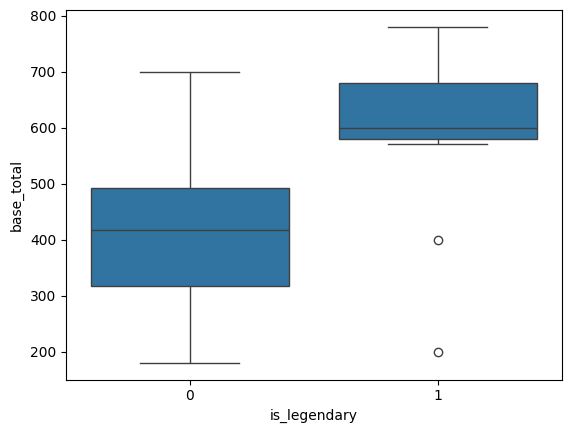

In [14]:
a= df.groupby('is_legendary')['base_total'].mean()
print(a)
sns.boxplot(data=df, x='is_legendary', y='base_total')
plt.show()


Is there a significant difference in Defense distribution between different Pokemon types?

type1
steel       120.208333
rock         97.090909
dragon       86.259259
ground       83.906250
ghost        79.518519
water        73.482456
ice          71.913043
grass        70.871795
bug          70.847222
dark         70.517241
poison       70.031250
psychic      69.264151
fairy        68.166667
fire         67.788462
fighting     66.392857
flying       65.000000
electric     61.820513
normal       59.695238
Name: defense, dtype: float64


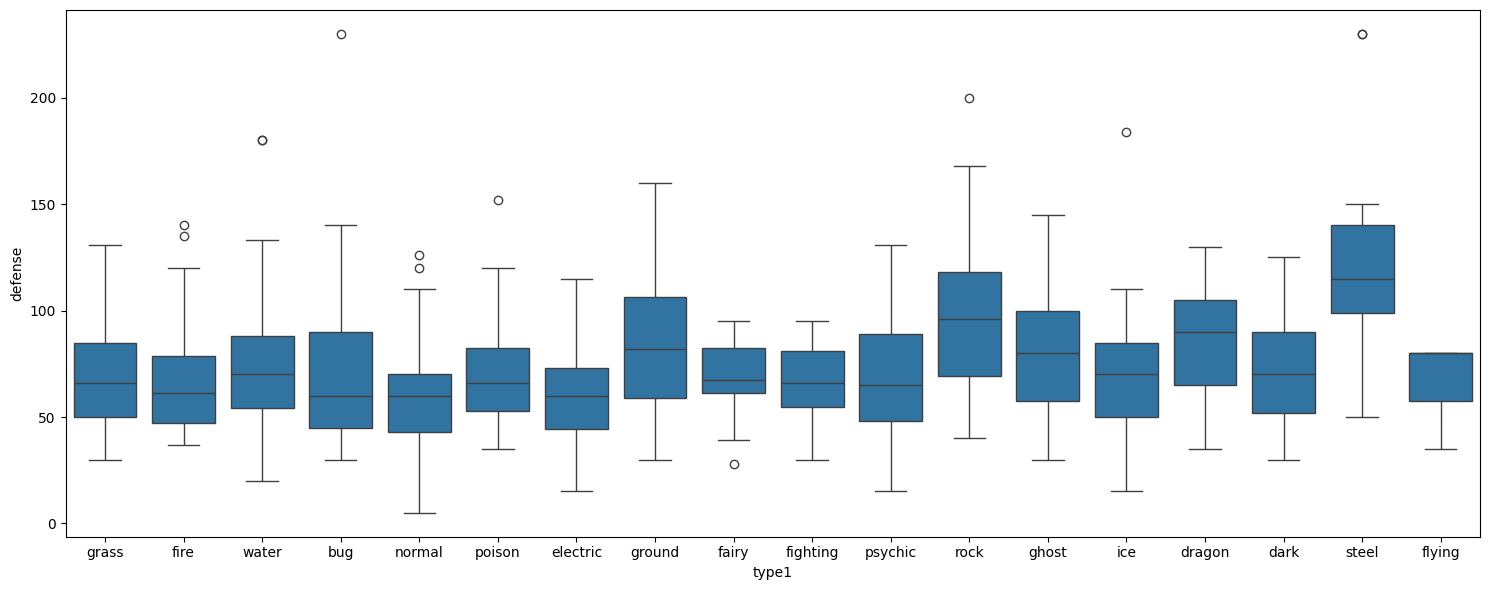

In [15]:
a = df.groupby('type1')['defense'].mean().sort_values(ascending=False)
print(a)
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='type1', y='defense')
plt.tight_layout()
plt.show()




Write a function that takes the name of a Pokemon as input and returns a dictionary containing its statistics.

In [19]:
def pokemon(name):
    b= df[df['name'].str.lower() == name.lower()]
    if b.empty:
        return f"There is no pokemon named {name}."
    return b.to_dict()

a = input("Enter pokemon name: ")
print(pokemon(a))




Enter pokemon name: fire
There is no pokemon named fire.


Fill in the blank values ​​in the Percentage_male column with the average of their type

In [17]:
avg=df.groupby('type1')['percentage_male'].transform('mean')
df['percentage_male']=df['percentage_male'].fillna(avg)
df

,#,name,type1,type2,base_total,hp,attack,defense,sp_attack,sp_defense,speed,height_m,weight_kg,is_legendary,generation,capture_rate,base_happiness,percentage_male,z_score
0,1,Bulbasaur,grass,poison,318,45,49,49,65,65,45,0.7,6.9,0,1,45,70,88.100000,-0.924833
1,2,Ivysaur,grass,poison,405,60,62,63,80,80,60,1.0,13.0,0,1,45,70,88.100000,-0.195281
2,3,Venusaur,grass,poison,625,80,100,123,122,120,80,2.0,100.0,0,1,45,70,88.100000,1.649564
3,4,Charmander,fire,NaN,309,39,52,43,60,50,65,0.6,8.5,0,1,45,70,88.100000,-1.000304
4,5,Charmeleon,fire,NaN,405,58,64,58,80,65,80,1.1,19.0,0,1,45,70,88.100000,-0.195281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,796,Celesteela,steel,flying,570,97,101,103,107,101,61,9.2,999.9,1,7,25,0,50.000000,1.188353
796,797,Kartana,grass,steel,570,59,181,131,59,31,109,0.3,0.1,1,7,255,0,58.978378,1.188353
797,798,Guzzlord,dark,dragon,570,223,101,53,97,53,43,5.5,888.0,1,7,15,0,50.550000,1.188353
798,799,Necrozma,psychic,NaN,600,97,107,101,127,89,79,2.4,230.0,1,7,3,0,51.058333,1.439923


In [18]:
df_gender = df[df['percentage_male'].isnull() == False]
df_gender['gender'] = ['male' if x > 50 else 'female' for x in df_gender['percentage_male']]
a= df_gender.groupby('gender')['base_total'].mean()
print(a)

gender
female    413.400338
male      470.658654
Name: base_total, dtype: float64


Is there a significant difference between the average weight and height of legendary and non-legendary Pokémon?

In [20]:
a = df.groupby('is_legendary')[['weight_kg', 'height_m']].mean()
print(a)


               weight_kg  height_m
is_legendary                      
0              48.018425  1.056681
1             199.350725  2.281159


Which combination of type 1 and type 2 is happier?

In [21]:
happiness= df.groupby(['type1', 'type2'])['base_happiness'].mean().sort_values(ascending=False).reset_index()
print(happiness.head(1))



     type1  type2  base_happiness
0  psychic  grass           100.0


Find average weights and heights by type

In [22]:
df.groupby('type1')[['weight_kg', 'height_m']].mean()



,weight_kg,height_m
type1,,
bug,33.083333,0.883333
dark,69.096552,1.296552
dragon,107.125926,1.937037
electric,37.944737,0.981579
fairy,23.555556,0.794444
fighting,58.675000,1.196429
fire,66.096000,1.168000
flying,52.000000,1.166667
ghost,69.570370,1.251852


If I want to choose the most ideal Pokemon to play, which one should I choose? To do this, conduct a specific analysis that suits you and justify the Pokemon you choose.

In [23]:
a = df[df['is_legendary'] == 1]
a['score'] = (a['base_total'] + a['speed'] + a['hp'] + a['attack'] + a['defense'])
b= a.sort_values(by='score', ascending=False).iloc[0]
b
print(f"İdeal Pokemon: {b['name']}")


İdeal Pokemon: Groudon


/tmp/ipykernel_6322/3596653771.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['score'] = (a['base_total'] + a['speed'] + a['hp'] + a['attack'] + a['defense'])


Create visualizations and build a dashboard based on the results of your analysis.


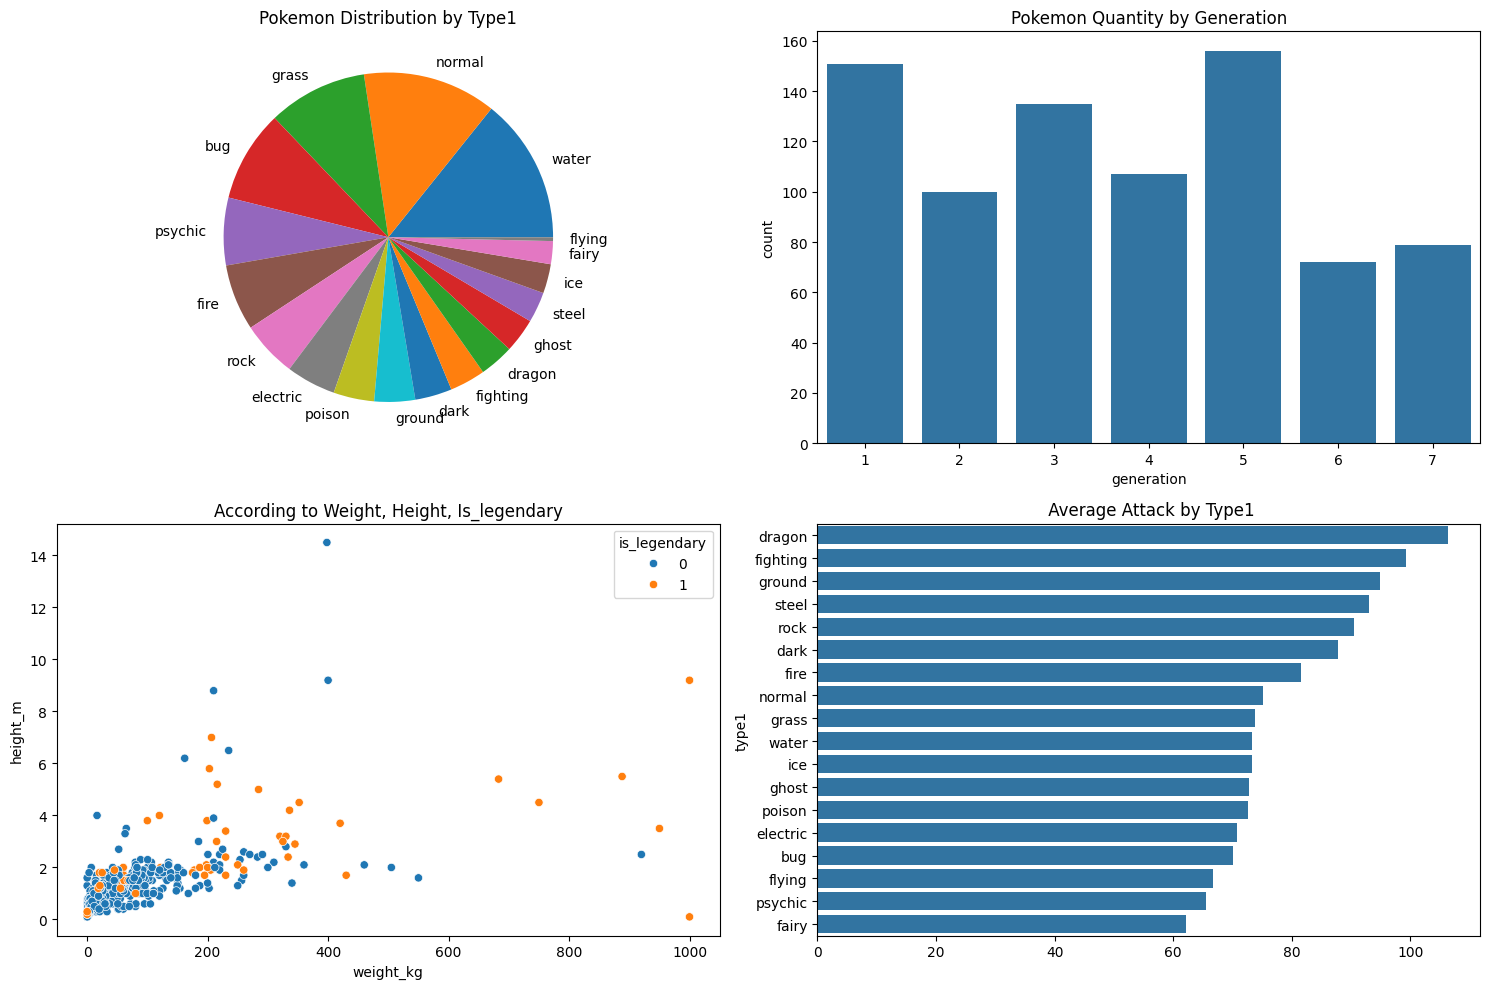

In [24]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
type_counts = df['type1'].value_counts()
plt.pie(type_counts, labels=type_counts.index)
plt.title("Pokemon Distribution by Type1")


plt.subplot(2, 2, 2)
sns.countplot(data=df, x='generation')
plt.title("Pokemon Quantity by Generation")


plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='weight_kg', y='height_m', hue='is_legendary')
plt.title("According to Weight, Height, Is_legendary")


plt.subplot(2, 2, 4)
c= df.groupby('type1')['attack'].mean().sort_values(ascending=False)
sns.barplot(x=c.values, y=c.index)
plt.title(" Average Attack by Type1")

plt.tight_layout()
plt.show()
